# ATDL qualitative web-image evaluation

One publicly sourced Wikimedia Commons image is downloaded for each CIFAR-10 class. This is an out-of-distribution qualitative diagnostic, not a benchmark: the images differ from CIFAR-10 acquisition, composition, and resolution. It does not alter the official test results or any frozen model decision.

In [1]:
from pathlib import Path
import io, json, sys, time
import requests
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path('/home/vu-lab03-pc17/ATDL-1').resolve()
OUT = ROOT / 'results/web_image_qualitative'
IMAGE_DIR = OUT / 'images'
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT))
CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
QUERIES = {'airplane':'airplane flying', 'automobile':'automobile car', 'bird':'bird', 'cat':'cat', 'deer':'deer', 'dog':'dog', 'frog':'frog', 'horse':'horse', 'ship':'ship vessel', 'truck':'truck'}
print('Output:', OUT)
print('Protocol: external Wikimedia Commons images; no training, tuning, or official-metric update.')

Output: /home/vu-lab03-pc17/ATDL-1/results/web_image_qualitative
Protocol: external Wikimedia Commons images; no training, tuning, or official-metric update.


In [2]:
# Download a JPEG/PNG thumbnail and preserve the Commons source/attribution metadata.
API = 'https://commons.wikimedia.org/w/api.php'
HEADERS = {'User-Agent': 'ATDL-educational-qualitative-evaluation/1.0'}
def fetch_commons_image(label, query):
    params = {'action':'query','format':'json','generator':'search','gsrsearch':query,'gsrnamespace':6,'gsrlimit':20,'prop':'imageinfo','iiprop':'url|mime|extmetadata','iiurlwidth':512}
    payload = requests.get(API, params=params, headers=HEADERS, timeout=30).json()
    pages = (payload.get('query') or {}).get('pages') or {}
    for page in pages.values():
        info = (page.get('imageinfo') or [{}])[0]
        url = info.get('thumburl') or info.get('url')
        mime = info.get('mime','')
        if not url or mime not in {'image/jpeg','image/png'}:
            continue
        try:
            response = requests.get(url, headers=HEADERS, timeout=45); response.raise_for_status()
            image = Image.open(io.BytesIO(response.content)).convert('RGB')
            if min(image.size) < 32:
                continue
            target = IMAGE_DIR / f'{label}.jpg'
            image.save(target, quality=95)
            meta = info.get('extmetadata', {})
            value = lambda key: (meta.get(key) or {}).get('value', '')
            return {'label':label, 'query':query, 'file':str(target.relative_to(ROOT)), 'commons_page':'https://commons.wikimedia.org/?curid='+str(page['pageid']), 'image_url':url, 'title':page.get('title',''), 'license':value('LicenseShortName'), 'artist':value('Artist'), 'credit':value('Credit')}
        except Exception as exc:
            print('Skipping candidate for', label, type(exc).__name__)
    raise RuntimeError(f'No downloadable Commons image found for {label}')

manifest_path = OUT/'web_image_manifest.json'
if manifest_path.exists():
    manifest = json.loads(manifest_path.read_text())
    assert [row['label'] for row in manifest['images']] == CLASSES
    print('Using preserved web-image manifest:', manifest_path)
else:
    rows = [fetch_commons_image(label, QUERIES[label]) for label in CLASSES]
    manifest = {'purpose':'qualitative external web-image robustness check; not a benchmark','source_platform':'Wikimedia Commons API','downloaded_at':time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),'images':rows}
    manifest_path.write_text(json.dumps(manifest, indent=2)+'\n')
    print('Downloaded', len(rows), 'external images and saved provenance.')

Downloaded 10 external images and saved provenance.


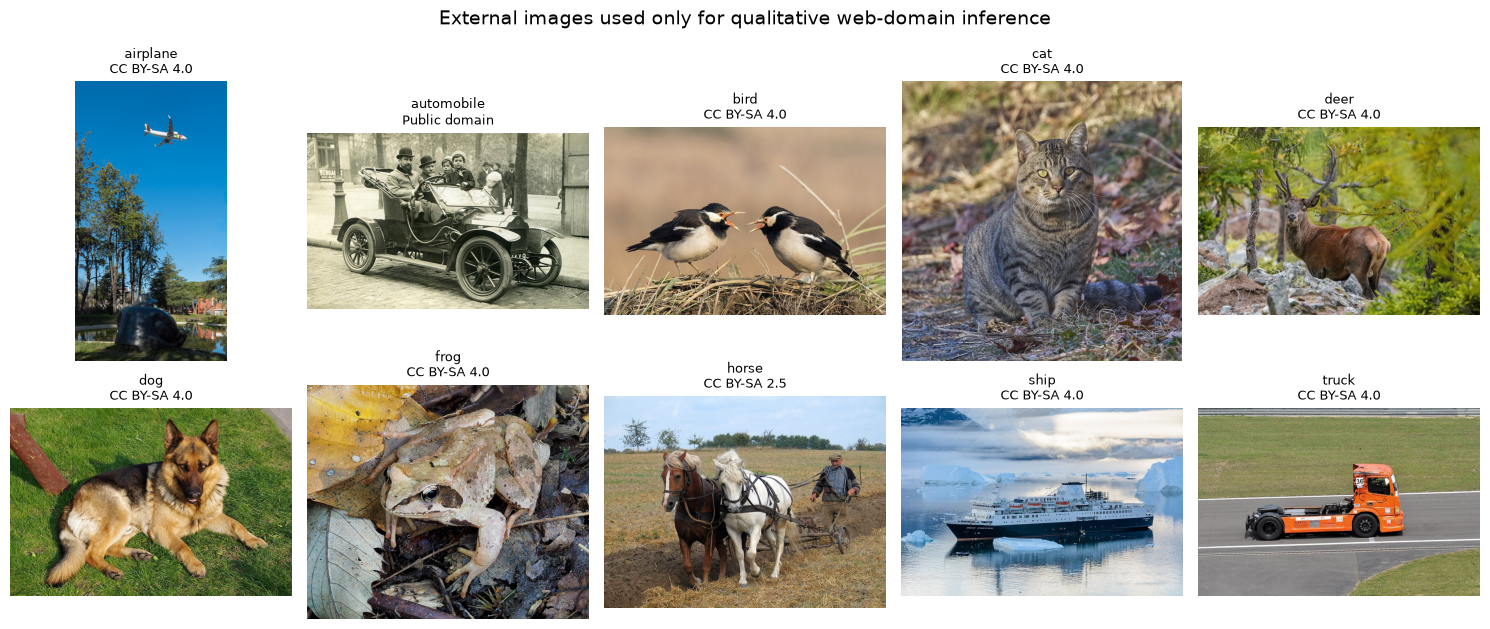

airplane   | File:"Infância" sculpture (Samuel Torres de Carvalho, 1993) with an airplane flying overhead, Jardim Mário Soares, Lisbon, Portugal julesvernex2.jpg | https://commons.wikimedia.org/?curid=180160048 | CC BY-SA 4.0
automobile | File:A Brouhot car in Paris, 1910.jpg | https://commons.wikimedia.org/?curid=17226541 | Public domain
bird       | File:Asian pied starlings (Gracupica contra).jpg | https://commons.wikimedia.org/?curid=64634352 | CC BY-SA 4.0
cat        | File:20231125 housecat south meadows PD100306.jpg | https://commons.wikimedia.org/?curid=141562823 | CC BY-SA 4.0
deer       | File:014 Wild Red Deer Switzerland Photo by Giles Laurent.jpg | https://commons.wikimedia.org/?curid=120575235 | CC BY-SA 4.0
dog        | File:20110425 German Shepherd Dog 8505.jpg | https://commons.wikimedia.org/?curid=15170790 | CC BY-SA 4.0
frog       | File:Agile frog (Rana dalmatina).jpg | https://commons.wikimedia.org/?curid=63042749 | CC BY-SA 4.0
horse      | File:04-09-12-Schaupflü

In [3]:
# Visual inspection of the ten downloaded images and their preserved source identifiers.
fig, axes = plt.subplots(2, 5, figsize=(15, 6.6))
for ax, row in zip(axes.flat, manifest['images']):
    ax.imshow(Image.open(ROOT/row['file']))
    ax.set_title(f"{row['label']}\n{row['license'] or 'license metadata unavailable'}", fontsize=9)
    ax.axis('off')
fig.suptitle('External images used only for qualitative web-domain inference', fontsize=14)
fig.tight_layout(); fig.savefig(OUT/'web_images_contact_sheet.png', dpi=180); plt.show()
for row in manifest['images']:
    print(f"{row['label']:10s} | {row['title']} | {row['commons_page']} | {row['license']}")

In [4]:
# Load only frozen, validation-selected checkpoints. No model is updated.
import torch
from torchvision import transforms
from scripts.run_official_final_evaluation import build_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHECKPOINTS = {
    'Teacher ResNet34': ROOT/'resnet34_cifar10_fp32_best.pth',
    'FP32 ResNet18': ROOT/'results/best_models/task2_b1_fp32_resnet18_best.pth',
    'Ternary ResNet18 no KD': ROOT/'results/best_models/task3_b2_default_best.pth',
    'Vanilla ternary KD control': ROOT/'experiments/task4/checkpoints/task4_b3_final_t2_lam09_remaining_rerun1/resnet18_ternary_kd_seed44.pth',
    'QTRD exploratory': ROOT/'results/task4/best_models/task11_qtrd_finaltwo_screen_t2_lam09_aux1_r1_best.pth',
}
models = {}
for name, path in CHECKPOINTS.items():
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    model, verification = build_model(checkpoint, device)
    models[name] = model
    print(name, '|', checkpoint['arch'], '| ternary=', None if verification is None else verification['all_ternary'])
preprocess = transforms.Compose([transforms.Resize((32, 32)), transforms.ToTensor(), transforms.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616))])

Teacher ResNet34 | ResNet34-CIFAR | ternary= None
FP32 ResNet18 | ResNet18-CIFAR | ternary= None


Ternary ResNet18 no KD | ResNet18-CIFAR-ternary | ternary= True


Vanilla ternary KD control | ResNet18-CIFAR-ternary | ternary= True


QTRD exploratory | ResNet18-CIFAR-ternary | ternary= True


In [5]:
# Independent top-3 predictions for every frozen model and every web image.
@torch.no_grad()
def predict(model, path):
    tensor = preprocess(Image.open(path).convert('RGB')).unsqueeze(0).to(device)
    probs = torch.softmax(model(tensor), dim=1)[0].cpu().numpy()
    top = probs.argsort()[-3:][::-1]
    return [{'class':CLASSES[i], 'probability':float(probs[i])} for i in top]

results = []
for row in manifest['images']:
    entry = {'label':row['label'], 'file':row['file'], 'source_page':row['commons_page'], 'license':row['license'], 'predictions':{}}
    for name, model in models.items():
        entry['predictions'][name] = predict(model, ROOT/row['file'])
    results.append(entry)

for name in models:
    correct = sum(entry['predictions'][name][0]['class'] == entry['label'] for entry in results)
    print(f'{name:28s}: {correct}/10 top-1 matches')
print('Interpretation: descriptive external-image matches only; this is not an accuracy estimate.')

Teacher ResNet34            : 9/10 top-1 matches
FP32 ResNet18               : 7/10 top-1 matches
Ternary ResNet18 no KD      : 6/10 top-1 matches
Vanilla ternary KD control  : 8/10 top-1 matches
QTRD exploratory            : 9/10 top-1 matches
Interpretation: descriptive external-image matches only; this is not an accuracy estimate.


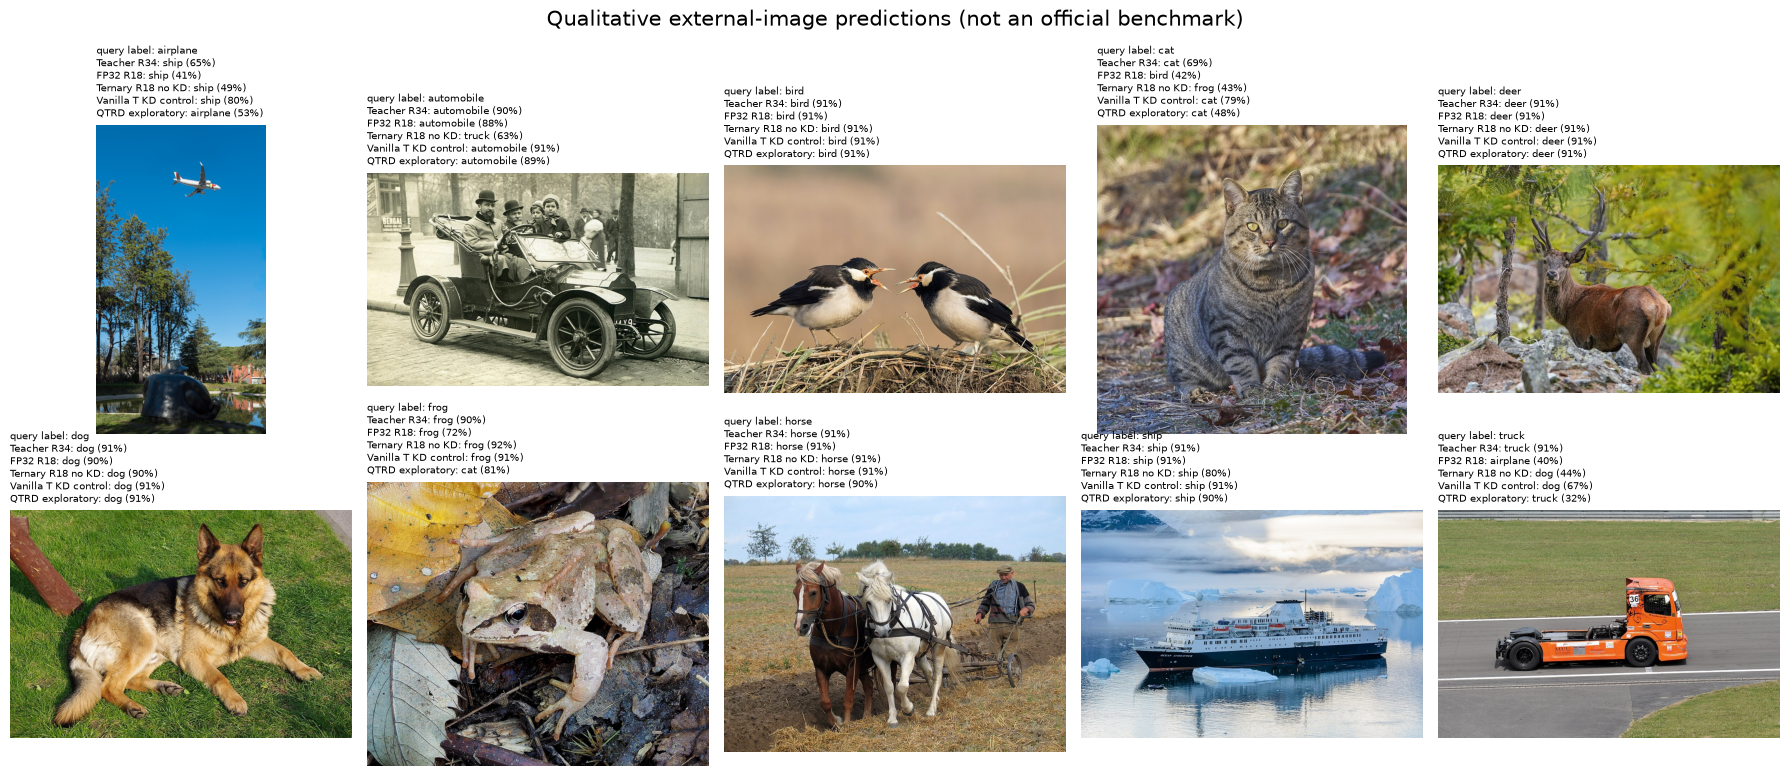

In [6]:
# Gallery: ground-truth query label and top-1 prediction from each frozen model.
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for ax, entry in zip(axes.flat, results):
    ax.imshow(Image.open(ROOT/entry['file']))
    lines = [f"query label: {entry['label']}"]
    for name, preds in entry['predictions'].items():
        first = preds[0]; lines.append(f"{name.replace(' ternary',' T').replace(' ResNet',' R')}: {first['class']} ({100*first['probability']:.0f}%)")
    ax.set_title('\n'.join(lines), fontsize=7.4, loc='left')
    ax.axis('off')
fig.suptitle('Qualitative external-image predictions (not an official benchmark)', fontsize=15)
fig.tight_layout(); fig.savefig(OUT/'web_image_prediction_gallery.png', dpi=200); plt.show()

In [7]:
# Persist the exact provenance and predictions, without modifying final-model selection or official results.
result_path = OUT/'web_image_predictions.json'
assert not result_path.exists(), f'Refusing to overwrite {result_path}'
payload = {'purpose':'qualitative out-of-distribution web-image inference; not a benchmark and not used for model selection','models':{name:str(path.relative_to(ROOT)) for name,path in CHECKPOINTS.items()},'images':manifest['images'],'results':results}
result_path.write_text(json.dumps(payload, indent=2)+'\n')
print('Saved:', result_path)
print('Official final evaluation remains:', ROOT/'results/final_official_test_evaluation.json')

Saved: /home/vu-lab03-pc17/ATDL-1/results/web_image_qualitative/web_image_predictions.json
Official final evaluation remains: /home/vu-lab03-pc17/ATDL-1/results/final_official_test_evaluation.json
